In [1]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from langchain.tools import tool
load_dotenv()

if os.environ['GOOGLE_API_KEY'] == "":
    raise ValueError("GOOGLE_API_KEY is not set in the .env file.")
else:
    print("GOOGLE_API_KEY is set correctly.")

GOOGLE_API_KEY is set correctly.


In [2]:
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash",)
llm

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.13', 'langchain-google-genai': '4.2.6'}}, output_version=None, profile={'name': 'Gemini 3.5 Flash', 'release_date': '2026-05-19', 'last_updated': '2026-05-19', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-3.5-flash', temperature=1.0, client=<google.genai.client.Client object at 0x00000249E71B9960>, default_metadata=(), model_kwargs={})

In [3]:
from pydantic import BaseModel, Field

class graph_schema(BaseModel):
    topic: str = Field(description="The topic to generate post.")
    linkedin_post: str = Field(description="LinkedIn post content.")
    insta_post: str = Field(description="Instagram post content.")
    twitter_post: str = Field(description="Twitter post content.")

In [4]:
def generate_linkedin_post(state: graph_schema) -> graph_schema:

    state = state.model_dump()  # Convert the Pydantic model to a dictionary

    topic = state['topic']

    linkedin_post = llm.invoke(f'Write a LinkedIn post about {topic} in 30 words. Keep the tone professional.').content[0].get('text')
    state['linkedin_post'] = linkedin_post

    return {"linkedin_post": linkedin_post}


def generate_insta_post(state: graph_schema) -> graph_schema:

    state = state.model_dump()  # Convert the Pydantic model to a dictionary

    topic = state['topic']

    insta_post = llm.invoke(f'Write an Instagram post about {topic} in 30 words. Keep the tone engaging.').content[0].get('text')
    state['insta_post'] = insta_post

    return {"insta_post": insta_post}


def generate_twitter_post(state: graph_schema) -> graph_schema:

    state = state.model_dump()  # Convert the Pydantic model to a dictionary

    topic = state['topic']

    twitter_post = llm.invoke(f'Write a Twitter post about {topic} in 30 words. Keep the tone concise.').content[0].get('text')
    state['twitter_post'] = twitter_post

    return {"twitter_post": twitter_post}

In [5]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)
graph.add_node("generate_linkedin_post", generate_linkedin_post)
graph.add_node("generate_insta_post", generate_insta_post)
graph.add_node("generate_twitter_post", generate_twitter_post)

graph.add_edge(START, "generate_linkedin_post")
graph.add_edge(START, "generate_insta_post")
graph.add_edge(START, "generate_twitter_post")
graph.add_edge("generate_linkedin_post", END)
graph.add_edge("generate_insta_post", END)
graph.add_edge("generate_twitter_post", END)

pydantic_graph = graph.compile()

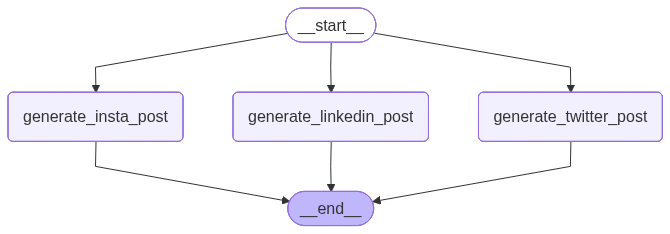

In [7]:
from IPython.display import Image, display

Image(pydantic_graph.get_graph().draw_mermaid_png())

In [6]:
pydantic_graph.invoke({"topic": "The future of AI in healthcare.", "linkedin_post": "", "insta_post": "", "twitter_post": ""})

{'topic': 'The future of AI in healthcare.',
 'linkedin_post': 'AI is transforming healthcare by enhancing diagnostic accuracy, streamlining workflows, and personalizing patient care. The future of medicine lies in the seamless collaboration between human clinical expertise and intelligent technology.',
 'insta_post': 'Imagine AI predicting illnesses before they start. 🩺 From instant diagnoses to personalized cures, the future of medicine is smarter, faster, and lifesaving. Are you ready for this healthcare revolution? #MedTech',
 'twitter_post': 'The future of healthcare is AI-driven. From precise diagnostics to personalized medicine, AI is making care smarter, faster, and saving lives daily. 🩺🤖 #MedTech #AI'}